In [ ]:
import pandas as pd
import numpy as np
import glob
import os

PATH_FOLDER = r'D:\Project_PA\data'
FILE_MASTER = os.path.join(PATH_FOLDER, 'Data_TMA_Manggarai_Merged.csv')
FILE_FINAL = os.path.join(PATH_FOLDER, 'Data_Final_Manggarai_Clean.csv')

def load_and_combine_data(path):
    all_files = glob.glob(os.path.join(path, "*.xls*"))
    df_list = []
    
    for f in all_files:
        filename = os.path.basename(f)
        print(f"Memproses: {filename}...")
        
        try:
            if f.endswith('.xlsx'):
                temp_df = pd.read_excel(f, engine='openpyxl')
            else:
                try:
                    temp_df = pd.read_html(f)[0]
                except:
                    temp_df = pd.read_html(f, flavor='html5lib')[0]
                        
            temp_df.columns = temp_df.columns.str.strip().str.lower()
            
            cols_to_keep = ['nama_pintu_air', 'tanggal', 'tinggi_air', 'status_siaga']
            temp_df = temp_df[cols_to_keep]
            df_list.append(temp_df)
            
        except Exception as e:
            print(f"Gagal total memproses {filename}: {e}")

    if not df_list:
        return pd.DataFrame()

    full_df = pd.concat(df_list, ignore_index=True)
    df_m = full_df[full_df['nama_pintu_air'].str.contains('Manggarai', case=False, na=False)].copy()
    return df_m

if not os.path.exists(FILE_MASTER):
    print("Memulai proses penggabungan file mentah...")
    df_manggarai = load_and_combine_data(PATH_FOLDER)
    df_manggarai.to_csv(FILE_MASTER, index=False)
else:
    print("File Master (Gabungan) ditemukan. Memuat data...")
    df_manggarai = pd.read_csv(FILE_MASTER)

print("Melakukan proses penyucian data (Data Sanitization)...")
df_fix = df_manggarai.copy()

df_fix['tanggal'] = pd.to_datetime(df_fix['tanggal'], errors='coerce')
df_fix = df_fix.dropna(subset=['tanggal'])
df_fix = df_fix[(df_fix['tanggal'].dt.year >= 2016) & (df_fix['tanggal'].dt.year <= 2020)]

df_fix['tinggi_air'] = pd.to_numeric(df_fix['tinggi_air'], errors='coerce')
df_fix = df_fix.dropna(subset=['tinggi_air'])

if df_fix['tinggi_air'].mean() > 2000:
    print("Satuan terdeteksi mm, mengonversi ke cm...")
    df_fix['tinggi_air'] = df_fix['tinggi_air'] / 10

df_fix = df_fix[(df_fix['tinggi_air'] >= 50) & (df_fix['tinggi_air'] <= 1200)]

df_fix = df_fix.sort_values('tanggal')
df_final = df_fix.set_index('tanggal').resample('h').mean(numeric_only=True)
df_final['tinggi_air'] = df_final['tinggi_air'].interpolate(method='linear')

df_final.to_csv(FILE_FINAL)
print(f"\nSelesai! Data Final disimpan di: {FILE_FINAL}")

File Master (Gabungan) ditemukan. Memuat data...
Melakukan proses penyucian data (Data Sanitization)...
Satuan terdeteksi mm, mengonversi ke cm...

Selesai! Data Final disimpan di: D:\Project_PA\data\Data_Final_Manggarai_Clean.csv


In [116]:
print(f"Jumlah data sebelum resample: {len(df_fix)}")
print(f"Jumlah data setelah resample: {len(df_final)}")

Jumlah data sebelum resample: 88691
Jumlah data setelah resample: 38226


In [117]:
from sklearn.preprocessing import MinMaxScaler

data = df_final[['tinggi_air']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Total data: {len(scaled_data)}")
print(f"Data latih: {len(train_data)}")
print(f"Data uji: {len(test_data)}")

Total data: 38226
Data latih: 30580
Data uji: 7646


In [118]:
def create_window(dataset, window_size=24, forecast_size=6):
    X, y = [], []
    for i in range(len(dataset) - window_size - forecast_size + 1):
        X.append(dataset[i:(i + window_size), 0])
        y.append(dataset[i + window_size + forecast_size - 1, 0]) 
    return np.array(X), np.array(y)

X_train, y_train = create_window(train_data, 24, 6)
X_test, y_test = create_window(test_data, 24, 6)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")

Shape X_train: (30551, 24, 1)
Shape y_train: (30551,)


In [119]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

d:\Project_PA\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
history = model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.0049 - val_loss: 0.0022
Epoch 2/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0022 - val_loss: 0.0013
Epoch 3/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 4/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 8.8329e-04 - val_loss: 0.0010
Epoch 5/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 6.8354e-04 - val_loss: 0.0010
Epoch 6/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 6.2016e-04 - val_loss: 9.1799e-04
Epoch 7/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 5.7398e-04 - val_loss: 8.9722e-04
Epoch 8/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 5.6523e-04 - val_loss: 9.2081e-04
Epoch 9/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 5.4737e-04 - val_loss: 8.5739e-04
Epoch 10/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 5.4361e-04 - val_loss: 8.5159e-04
Epoch 11/35
955/955 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 5.3167e-

In [121]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

predictions = model.predict(X_test)

y_pred_cm = scaler.inverse_transform(predictions)
y_test_cm = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(y_test_cm, y_pred_cm))
mae = mean_absolute_error(y_test_cm, y_pred_cm)
r2 = r2_score(y_test_cm.flatten(), y_pred_cm.flatten())

print(f"Metrik Evaluasi SIPMA (t+6):")
print(f"RMSE : {rmse:.4f} cm")
print(f"MAE  : {mae:.4f} cm")
print(f"R2   : {r2:.4f}")

239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Metrik Evaluasi SIPMA (t+6):
RMSE : 25.4271 cm
MAE  : 12.8734 cm
R2   : 0.7932


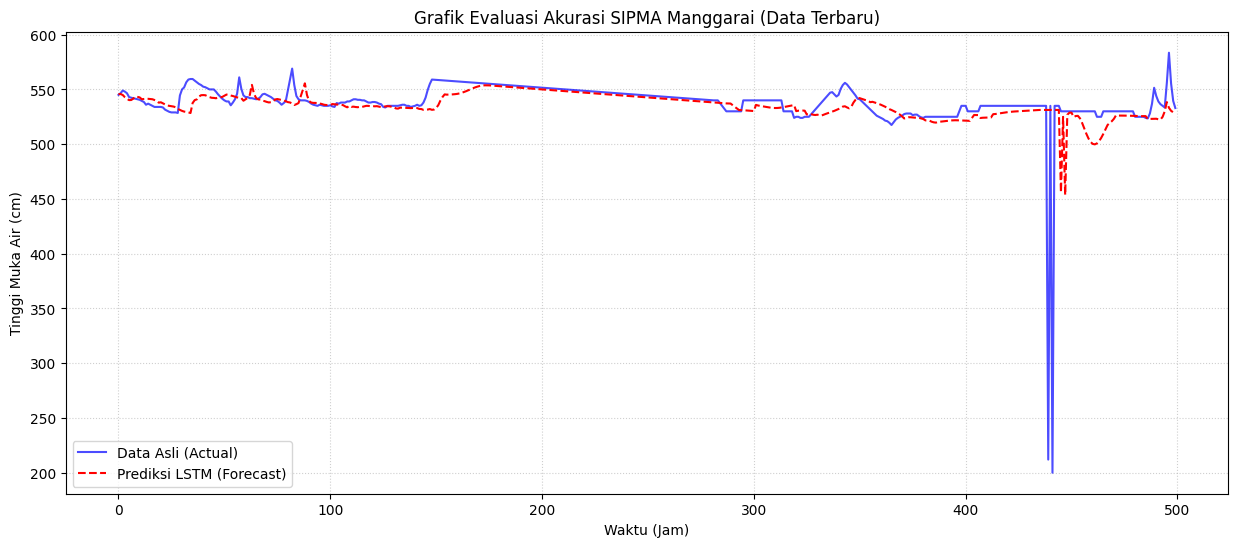

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(y_test_cm[-500:, 0], label='Data Asli (Actual)', color='blue', alpha=0.7)
plt.plot(y_pred_cm[-500:, 0], label='Prediksi LSTM (Forecast)', color='red', linestyle='--')

plt.title('Grafik Evaluasi Akurasi SIPMA Manggarai (Data Terbaru)')
plt.xlabel('Waktu (Jam)')
plt.ylabel('Tinggi Muka Air (cm)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [123]:
df_fix['bulan_tahun'] = df_fix['tanggal'].dt.to_period('M')
print(df_fix['bulan_tahun'].value_counts().sort_index().tail(20))

bulan_tahun
2019-05    1485
2019-06    1436
2019-07    1480
2019-08    1000
2019-09    1417
2019-10    1448
2019-11    1099
2019-12    1201
2020-01    1478
2020-02     987
2020-03    1474
2020-04     802
2020-05    1003
2020-06    1396
2020-07    1479
2020-08    1478
2020-09    1425
2020-10    1360
2020-11    1233
2020-12    1416
Freq: M, Name: count, dtype: int64


In [124]:
print("Cek 5 data asli pertama:", y_test_cm[:5, 0])
print("Cek 5 data prediksi pertama:", y_pred_cm[:5, 0])

Cek 5 data asli pertama: [627.         630.05882353 633.11764706 636.17647059 639.23529412]
Cek 5 data prediksi pertama: [624.7494  624.80316 624.85693 624.91064 624.9644 ]


In [125]:
print("Tahun yang tersedia di df_fix:")
print(df_fix['tanggal'].dt.year.unique())

print("\nJumlah data per tahun:")
print(df_fix['tanggal'].dt.year.value_counts().sort_index())

Tahun yang tersedia di df_fix:
[2016 2017 2018 2019 2020]

Jumlah data per tahun:
tanggal
2016     5353
2017     9701
2018    37798
2019    20308
2020    15531
Name: count, dtype: int64


In [126]:
import joblib

# Folder simpan
MODEL_PATH = r'D:\Project_PA\models'
if not os.path.exists(MODEL_PATH):
    os.makedirs(MODEL_PATH)

model.save(os.path.join(MODEL_PATH, 'model_lstm_manggarai.h5'))
joblib.dump(scaler, os.path.join(MODEL_PATH, 'scaler_tma.sav'))

print(f"Model dan Scaler BERHASIL diamankan di: {MODEL_PATH}")

Model dan Scaler BERHASIL diamankan di: D:\Project_PA\models
